# Propensity Score & DML

- IPW, AIPW, Doubly Robust Estimator

### Propensity Score 추정

출처: https://matheusfacure.github.io/python-causality-handbook/11-Propensity-Score.html

IPW와 AIPW, Doubly Robust 모두 Propensity Score를 활용한 개념들이기 때문에 먼저 Propensity Score부터 간단하게 구해보겠습니다.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from causalinference import CausalModel

In [2]:
data = pd.read_csv("../data/matheus_data/learning_mindset.csv")
data.sample(5, random_state=5)

,schoolid,intervention,achievement_score,success_expect,ethnicity,gender,frst_in_family,school_urbanicity,school_mindset,school_achievement,school_ethnic_minority,school_poverty,school_size
259,73,1,1.480828,5,1,2,0,1,-0.462945,0.652608,-0.515202,-0.169849,0.173954
3435,76,0,-0.987277,5,13,1,1,4,0.334544,0.648586,-1.310927,0.224077,-0.426757
9963,4,0,-0.152340,5,2,2,1,0,-2.289636,0.190797,0.875012,-0.724801,0.761781
4488,67,0,0.358336,6,14,1,0,4,-1.115337,1.053089,0.315755,0.054586,1.862187
2637,16,1,1.360920,6,4,1,0,1,-0.538975,1.433826,-0.033161,-0.982274,1.591641


Propensity Score 계산

In [3]:
categ = ["ethnicity", "gender", "school_urbanicity"]
cont = ["school_mindset", "school_achievement", "school_ethnic_minority", "school_poverty", "school_size"]

data_with_categ = pd.concat([
    data.drop(columns=categ), 
    pd.get_dummies(data[categ], columns=categ, drop_first=False)
], axis=1)

In [4]:
from sklearn.linear_model import LogisticRegression

T = 'intervention'
Y = 'achievement_score'
X = data_with_categ.columns.drop(['schoolid', T, Y])

ps_model = LogisticRegression(C=1e6).fit(data_with_categ[X], data_with_categ[T])

data_ps = data.assign(propensity_score=ps_model.predict_proba(data_with_categ[X])[:, 1])

## IPW 및 ATE 추정

In [5]:
import pandas as pd
from sklearn.linear_model import LogisticRegression, Ridge
from causallib.estimation.standardization import Standardization
from causallib.estimation.ipw import IPW
from causallib.estimation.doubly_robust import AIPW

#### 1) IPW로 가상(Pseudo) 모집단 생성    

표본의 각 개체에 IPW 적용      


In [6]:
weight_t = 1/data_ps.query("intervention==1")["propensity_score"]
weight_nt = 1/(1-data_ps.query("intervention==0")["propensity_score"])
print("Original Sample Size", data.shape[0])
print("Treated Population Sample Size", sum(weight_t))
print("Untreated(Control) Population Sample Size", sum(weight_nt))

Original Sample Size 10391
Treated Population Sample Size 10387.611324207002
Untreated(Control) Population Sample Size 10391.506162305861


#### 2) ATE 추정

이제 Pseudo 집단에서의 Treat그룹과 Control그룹 각각의 Average Potential Outcome을 구하고, 이를 토대로 ATE를 추정합니다.

In [7]:
weight = ((data_ps["intervention"]-data_ps["propensity_score"]) /
          (data_ps["propensity_score"]*(1-data_ps["propensity_score"])))

y1_ipw = sum(data_ps.query("intervention==1")["achievement_score"]*weight_t) / len(data)
y0_ipw = sum(data_ps.query("intervention==0")["achievement_score"]*weight_nt) / len(data)

ate_ipw = y1_ipw - y0_ipw
#ate = np.mean(weight * data_ps["achievement_score"]) -> 이렇게도 ATE 계산 가능

print("Y1:", y1_ipw)
print("Y0:", y0_ipw)
print("ATE", np.mean(weight * data_ps["achievement_score"]))

Y1: 0.25981027799629486
Y0: -0.12903052783749974
ATE 0.38884080583379527


**결과 해석**: 
1. Treatment 받은 개인이 Treatment 받지 않은 동료보다 achievement_score가 0.38 표준편차 더 크다. (achievement_score는 표준화된 결과이기 때문에 표준 편차의 차이로 해석)
2. 아무도 Treatment 받지 않은 경우 일반적인 성취 수준이 현재보다 0.12 표준편차 더 낮다.
3. 모든 사람이 Treatment(세미나)를 받았다면 일반적인 성취 수준이 0.25 표준편차 더 높음.

또한 ate를 나타내는 하나의 코드가 더 있다.     
위의 코드에 주석처리한 부분을 그대로 실행해보면 똑같은 결과를 얻을 수 있는 것을 알 수 있다.

두 결과값이 같은 이유는 Matheus Facure(출처)의 책에서 자세히 설명되어 있다.    
(참고: $ \mathrm{ATE}=\mathbb{E}\!\left[\, Y\,\dfrac{T-e(X)}{e(X)\,\bigl(1-e(X)\bigr)} \right] $)

## Doubly Robust Estimator & AIPW

출처: https://causallib.readthedocs.io/en/latest/causallib.estimation.doubly_robust.html?highlight=doubly

In [8]:
from sklearn.model_selection import KFold
from causallib.estimation.ipw import IPW
from causallib.estimation.doubly_robust import AIPW
from causallib.estimation.standardization import Standardization
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge

In [9]:
Y = data["achievement_score"]
T = data["intervention"]
X = pd.get_dummies(
    data[["school_mindset","school_achievement","school_ethnic_minority",
          "school_poverty","school_size","ethnicity","gender","school_urbanicity"]],
    drop_first=False
)

DR Estimator는 결과모형과 IPW값이 모두 필요함   
- Y값(achievement_score)을 Ridge로 예측(L2 패널티 부여)   
- IPW: 로지스틱 회귀 사용

In [10]:
outcome_model = Standardization(learner=Ridge(alpha=1.0))
weight_model  = IPW(learner=LogisticRegression(max_iter=1000),
                    clip_min=0.01, clip_max=0.99, use_stabilized=True)

Propensity Score를 구할 때 max_iter을 충분히 큰 숫자(1000)으로 설정해 수치 최적화가 수렴할 수 있도록 설정합니다.   
또한 클리핑을 사용하여 $ \hat{e} $가 [0.01, 0.99]에서만 존재하도록 극단 가중치를 완화합니다 (use_stabilized = True).  

#### AIPW 추정

위에서 구한 PS와 IPW를 활용하여 AIPW를 구합니다.

In [11]:
dr = AIPW(outcome_model=outcome_model, weight_model=weight_model, overlap_weighting=False)
dr.fit(X, T, Y)

AIPW(_doc_link_module=sklearn, _doc_link_template=https://scikit-learn.org/1.5/modules/generated/{estimator_module}.{estimator_name}.html, _doc_link_url_param_generator=None, outcome_covariates=None, outcome_model=Standardization(_doc_link_module=sklearn, _doc_link_template=https://scikit-learn.org/1.5/modules/generated/{estimator_module}.{estimator_name}.html, _doc_link_url_param_generator=None, encode_treatment=False, predict_proba=False,
                learner=Ridge()), overlap_weighting=False, predict_proba=False, weight_covariates=None,
     weight_model=IPW(_doc_link_module=sklearn, _doc_link_template=https://scikit-learn.org/1.5/modules/generated/{estimator_module}.{estimator_name}.html, _doc_link_url_param_generator=None, clip_max=0.99, clip_min=0.01, use_stabilized=True, verbose=False,
    learner=LogisticRegression(max_iter=1000)))

In [12]:
pop_outcomes = dr.estimate_population_outcome(X, T, Y)
mu1_aipw, mu0_aipw = pop_outcomes[1], pop_outcomes[0]
ate_aipw = dr.estimate_effect(mu1_aipw, mu0_aipw, agg="population")["diff"]
print("μ1 (A=1):", mu1_aipw)
print("μ0 (A=0):", mu0_aipw)
print("ATE (DR, vanilla):", ate_aipw)

μ1 (A=1): 0.30329930792804977
μ0 (A=0): -0.1471130386820095
ATE (DR, vanilla): 0.45041234661005924


**결과 해석**

결과 해석은 IPW에서와 마찬가지로 생각하면 됩니다.  

위에서 구한 AIPW는 Propensity Score의 Overlap이 충분히 확보되었을 때는 좋은 결과를 나타냅니다.   
하지만 Overlap 구간이 불안정할 때는 Overlap-weighting = True이라는 기능을 활용해도 좋습니다.

In [13]:
dr_overlap = AIPW(outcome_model=outcome_model,
                  weight_model=weight_model,
                  overlap_weighting=True)
dr_overlap.fit(X, T, Y)

AIPW(_doc_link_module=sklearn, _doc_link_template=https://scikit-learn.org/1.5/modules/generated/{estimator_module}.{estimator_name}.html, _doc_link_url_param_generator=None, outcome_covariates=None, outcome_model=Standardization(_doc_link_module=sklearn, _doc_link_template=https://scikit-learn.org/1.5/modules/generated/{estimator_module}.{estimator_name}.html, _doc_link_url_param_generator=None, encode_treatment=False, predict_proba=False,
                learner=Ridge()), overlap_weighting=True, predict_proba=False, weight_covariates=None,
     weight_model=IPW(_doc_link_module=sklearn, _doc_link_template=https://scikit-learn.org/1.5/modules/generated/{estimator_module}.{estimator_name}.html, _doc_link_url_param_generator=None, clip_max=0.99, clip_min=0.01, use_stabilized=True, verbose=False,
    learner=LogisticRegression(max_iter=1000)))

In [14]:
pop_outcomes_ov = dr_overlap.estimate_population_outcome(X, T, Y)
ate_ov = dr_overlap.estimate_effect(pop_outcomes_ov[1], pop_outcomes_ov[0],
                                    agg="population")["diff"]
print(" ATE(DR, overlap-weighting):", ate_ov)

 ATE(DR, overlap-weighting): 0.3467411782171299


### Summary

In [15]:
results = pd.DataFrame([
    ["IPW (manual)",      y1_ipw,    y0_ipw,    ate_ipw],
    ["AIPW (vanilla)",    mu1_aipw,  mu0_aipw,  ate_aipw],
    ["AIPW (overlap)",    np.nan,    np.nan,    ate_ov]
], columns=["estimator", "μ1", "μ0", "ATE"])
print(results)

        estimator        μ1        μ0       ATE
0    IPW (manual)  0.259810 -0.129031  0.388841
1  AIPW (vanilla)  0.303299 -0.147113  0.450412
2  AIPW (overlap)       NaN       NaN  0.346741


위에서 사용한 방법에 따라 ATE 값이 다르게 나타나는 것을 알 수 있습니다.   
  
하지만 Overlap-Weighting 옵션을 사용한 경우에는 ATE가 아닌 ATO를 추정한 것이고 둘을 직접 비교하는 것은 맞지 않을 수 있습니다.   
  
분석의 목적이 ATE를 추정하는 것인지 ATO를 추정하는 것인지 확인한 후 적절히 사용하면 됩니다.   

## Robustness Check의 흐름

각각의 수치에 대한 검증은 필수입니다.  
어떤 수치가 더 Robust하게 추정이 된 걸까요?   

Yang et al., 2019, Gastrointest Endosc 및 Austin, 2021, Statistic in Medicine 논문을 참고하여 IPW에 대한 Robustness Check을 진행해보도록 하겠습니다.    
순서는 다음과 같습니다.

1) **IPW 가중 전, 후 |SMD| 변화 확인**

2) **Propensity Score의 Overlap 확인**

3) **IPW 가중 이후 ESS 및 VIF 확인**

먼저 IPW로 구한 ATE의 신빙성을 테스트 해보겠습니다.

출처: https://causallib.readthedocs.io/en/latest/causallib.evaluation.plots.plots.html

In [16]:
import matplotlib.pyplot as plt
from causallib.evaluation.plots.plots import plot_propensity_score_distribution
from causallib.evaluation import evaluate

### IPW 가중 전, 후 |SMD| 변화 확인

<Axes: xlabel='Absolute Standard Mean Difference', ylabel='Covariates'>

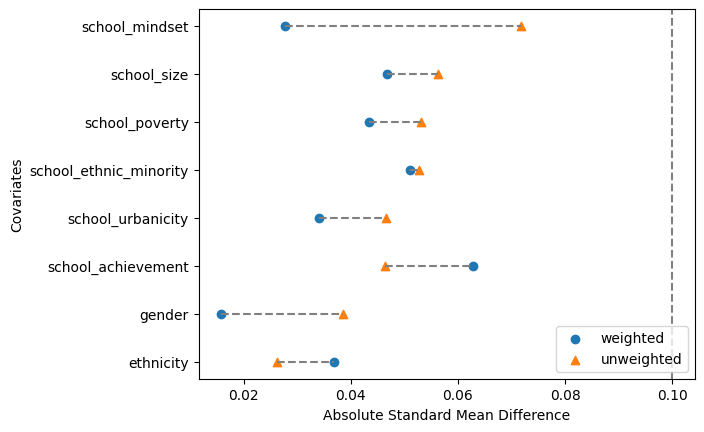

In [17]:
res = evaluate(weight_model, X, T, Y, cv="auto")
res.plot_covariate_balance(kind="love", phase="valid", thresh=0.1)

Weighted이후에 |SMD|가 더 줄어든 것을 보았을 때, Weighted 이후 밸런스가 개선되었음을 확인할 수 있습니다.    
|SMD| < 0.1 이 목표

### Propensity Score Overlap
아래는 처음에 Logistic Regression으로 추정한 Propensity Score의 Distribution을 나타낸 것입니다.

<Axes: title={'center': 'Propensity Distribution'}, xlabel='Propensity', ylabel='Probability density'>

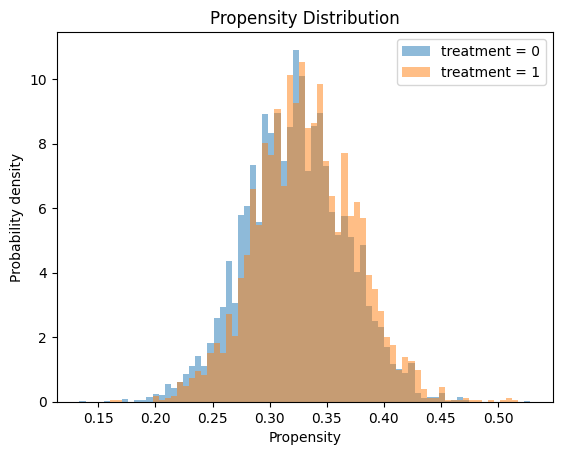

In [18]:
plot_propensity_score_distribution(
    propensity=data_ps['propensity_score'],
    treatment=data_ps['intervention'],
    reflect=False,
    kde=False,
    norm_hist=True,
)

하지만 이는 하나의 데이터에 적합 및 예측을 동시에 하기 때문에 Overlap이 실제보다 좋아보일 수 있습니다.

그렇다면 OOF 폴드 예측으로 얻은 PS 분포를 그려봅시다.   
(cv = None -> 단일 적합, cv = "auto" -> 교차검증)

<Axes: title={'center': 'Propensity Distribution'}, xlabel='Propensity', ylabel='Probability density'>

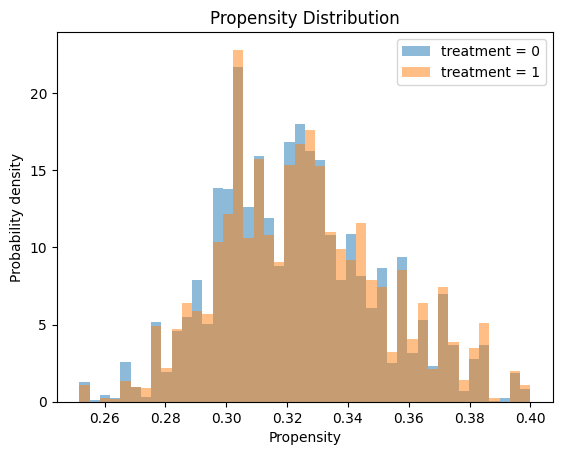

In [19]:
res.plot_weight_distribution(phase="valid", reflect=False, norm_hist=True)

OOF로 검증해도 Propensity Score의 Overlap 및 Positivity가 양호한 것을 확인

### IPW 가중치 분포 및 유효표본수(ESS)

In [20]:
w = weight_model.compute_weights(X, T)
ESS = (w.sum()**2) / (w**2).sum()
N   = len(w)
VIF = N / ESS

print(f"ESS = {ESS:.2f} (N = {N})  ->  VIF = {VIF:.4f}")

ESS = 10354.68 (N = 10391)  ->  VIF = 1.0035


Text(0.5, 1.0, 'IPW weights (log y)')

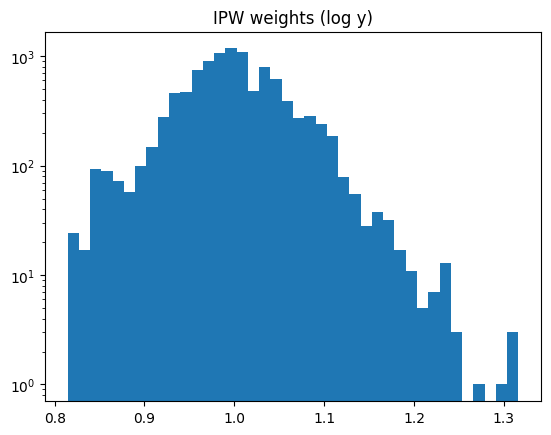

In [21]:
plt.figure(); plt.hist(w, bins=40); plt.yscale('log'); plt.title('IPW weights (log y)')

결과 해석
1) ESS와 N수가 거의 비슷한 것을 확인할 수 있음(VIF ≈ 1) -> 가중치가 고르게 퍼져있다
2) 히스토그램이 1 주변에 모여있고(= 가중치 과도하게 쏠리지 않음), 꼬리 부분도 완만(= 극단 가중치 거의 없음)



다만 VIF와 Propensity Score Overlap이 정량적으로 얼마나 되어야 한다 라는 지표는 찾을 수 없었습니다.    


데이터 및 분석의 맥락에 따라 다르게 지정하되, propensity score의 overlap이 약하다면 위에서 진행한 clipping 등의 방법을 적용해보면 좋습니다. 

[참고자료]
- Yang, Jeff Y., et al. "Propensity score methods to control for confounding in observational cohort studies: a statistical primer and application to endoscopy research." Gastrointestinal endoscopy 90.3 (2019): 360-369.

- Austin, Peter C. "Informing power and sample size calculations when using inverse probability of treatment weighting using the propensity score." Statistics in Medicine 40.27 (2021): 6150-6163.



## Double/Debiased Machine Learning (비모수 버전의 Regression 처럼 활용 가능)

코드 및 데이터 참조 출처: https://matheusfacure.github.io/python-causality-handbook/22-Debiased-Orthogonal-Machine-Learning.html

DML은 ATE와 CATE와 같은 인과적 모수를 구하는 하나의 프레임입니다.   

간략하게 소개하자면, DML은 복잡한 보조모형은 머신러닝으로 학습하고, 직교화(Neyman 점수)와 교차적합으로 bias를 상쇄해 ATE·CATE 같은 인과모수를 정규성으로 안정적으로 추정하는 프레임워크입니다.             
이를 통해 인과 매개변수의 추정 절차와 성가신 매개변수의 추정 절차를 분리할 수 있는 장점을 지닌 방법입니다.

코드와 함께 더 자세하게 알아보기 위해 계량경제학에서 자주 사용하는 데이터셋 중 하나인 **아이스크림 판매 데이터셋**을 활용해보겠습니다.  


In [29]:
test = pd.read_csv("../data/matheus_data/ice_cream_sales_rnd.csv")
train = pd.read_csv("../data/matheus_data/ice_cream_sales.csv")
train.head()

,temp,weekday,cost,price,sales
0,17.3,6,1.5,5.6,173
1,25.4,3,0.3,4.9,196
2,23.3,5,1.5,7.6,207
3,26.9,1,0.3,5.3,241
4,20.2,1,1.0,7.2,227


### Frisch-Waugh-Lovell 응용 DML

In [35]:
y = "sales"
T = "price"
X = ["temp", "weekday", "cost"]

debias_m = LGBMRegressor(max_depth=3, verbosity=-1)
denoise_m = LGBMRegressor(max_depth=3, verbosity=-1)

train_pred = train.assign(price_res =  train[T] - cross_val_predict(debias_m, train[X], train[T], cv=5),
                          sales_res =  train[y] - cross_val_predict(denoise_m, train[X], train[y], cv=5))

위의 코드는 FWL(Frisch-Waugh-Lovell) 정리($Y_i - \mathbb{E}[Y_i\mid X_i] = \tau\,(T_i - \mathbb{E}[T_i\mid X_i]) + \varepsilon$)에서 $ \mathbb{E}[Y_i\mid X_i] $ 와 $\mathbb{E}[T_i\mid X_i] $를 머신러닝을 사용하여 추정합니다.    
-> $Y_i - \mathbb{E}[Y_i\mid X_i] = \tau\,(T_i - \mathbb{E}[T_i\mid X_i]) + \varepsilon$)에서 $

이를 통해 Y와 T의 잔차를 추정할 때 교호작용(변수 간의 Interaction)과 비선형성을 모델링할 수 있고, 동시에 FWL 스타일의 직교화를 유지할 수 있게끔 합니다.     

변수명을 debias_m, 그리고 denoise_m이라고 지정한 이유는 무엇일까요?    

먼저 debias_m은 FWL 정리의 식에서 $T - M_t( = \tilde{T})$부분으로, X의 모든 교란 편향이 모델에 의해 제거된 부분입니다.($M_t := \mathbb{E}[T_i\mid X_i]$를 머신러닝으로 추정한 모델)        
즉, $\tilde{T}$는 X에 직교하는, X로 인한 bias를 없앤 값입니다.    

마찬가지로 denoise_m은 FWL 식에서 $Y - M_y(= \tilde{Y})$부분으로, Y에서 분산을 제거하는 부분입니다.($M_y := \mathbb{E}[Y_i\mid X_i]$를 머신러닝으로 추정한 모델)    
즉, $\tilde{Y}$는 X로 인한 모든 분산이 제거된 값입니다.

위에서 구한 모델을 활용하여 최종 ATE를 구해봅시다.

In [37]:
import statsmodels.formula.api as smf

final_model = smf.ols(formula='sales_res ~ price_res', data=train_pred).fit()
final_model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.0106,0.072,0.148,0.883,-0.131,0.152
price_res,-3.9228,0.071,-54.962,0.000,-4.063,-3.783


위와 같이 최종 ATE 추정 시에는 간단하게 선형으로 ATE를 추정할 수 있습니다.     
    
하지만 이는 결국 True Y값이 비선형적인 모습을 띄고 있다면 ATE를 제대로 추정하지 못하게 되는 단점을 가지고 있습니다.        

그래서 우리는 비모수 이중/탈편향 기계학습 방법을 통해 최종 모델까지도 비선형 ML을 사용하는 방법을 알아볼 것입니다.

#### 비모수 이중/탈편향 기계학습

### 질문이나 의견을 남겨주세요.
<script src="https://utteranc.es/client.js"
        repo="CausalInferenceLab/awesome-causal-inference-python"
        issue-term="pathname"
        theme="github-light"
        crossorigin="anonymous"
        async>
</script>